# 2.3 Random Forest Model

## Table of Contents
### 1. Import Libraries and Data

## 1. Import Libraries and Data

In [51]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn import datasets  
from sklearn.ensemble import RandomForestClassifier
from numpy import argmax
from sklearn.model_selection import train_test_split
from sklearn import metrics  
from sklearn.tree import plot_tree
from sklearn import tree
import warnings

In [52]:
# Import unscaled weather data
path = r'/Users/daxma/OneDrive/Desktop/Data Analytics/Machine Learning with Python/07-25 ClimateWins Analysis/02 Data'

In [53]:
df = pd.read_csv(os.path.join(path,'Prepared Data', 'weather_unscaled_clean.csv'))

In [54]:
# Check output
df.head()

,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max,BELGRADE_cloud_cover,...,STOCKHOLM_temp_max,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
0,7,0.85,1.018,0.32,0.09,0.7,6.5,0.8,10.9,1,...,4.9,5,0.88,1.0003,0.45,0.34,4.7,8.5,6.0,10.9
1,6,0.84,1.018,0.36,1.05,1.1,6.1,3.3,10.1,6,...,5.0,7,0.91,1.0007,0.25,0.84,0.7,8.9,5.6,12.1
2,8,0.90,1.018,0.18,0.30,0.0,8.5,5.1,9.9,6,...,4.1,7,0.91,1.0096,0.17,0.08,0.1,10.5,8.1,12.9
3,3,0.92,1.018,0.58,0.00,4.1,6.3,3.8,10.6,8,...,2.3,7,0.86,1.0184,0.13,0.98,0.0,7.4,7.3,10.6
4,6,0.95,1.018,0.65,0.14,5.4,3.0,-0.7,6.0,8,...,4.3,3,0.80,1.0328,0.46,0.00,5.7,5.7,3.0,8.4


In [55]:
# Import pleasant weather answers
pleasant = pd.read_csv(os.path.join(path, 'Original Data', 'Pleasant_Weather_Answers.csv'))

In [56]:
# Check output
pleasant.head()

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
0,19600101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,19600102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,19600103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,19600104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,19600105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 2. Data Wrangling

In [58]:
# Generate a date range starting from 1960-01-01 with the same number of rows as df_unscaled
date_range = pd.date_range(start='1960-01-01', periods=len(df), freq='D')

# Add the DATE column back
df['DATE'] = date_range

# Move DATE to first column
cols = ['DATE'] + [col for col in df.columns if col != 'DATE']
df = df[cols]

In [59]:
# Check output
df.head()

,DATE,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max,...,STOCKHOLM_temp_max,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
0,1960-01-01,7,0.85,1.018,0.32,0.09,0.7,6.5,0.8,10.9,...,4.9,5,0.88,1.0003,0.45,0.34,4.7,8.5,6.0,10.9
1,1960-01-02,6,0.84,1.018,0.36,1.05,1.1,6.1,3.3,10.1,...,5.0,7,0.91,1.0007,0.25,0.84,0.7,8.9,5.6,12.1
2,1960-01-03,8,0.90,1.018,0.18,0.30,0.0,8.5,5.1,9.9,...,4.1,7,0.91,1.0096,0.17,0.08,0.1,10.5,8.1,12.9
3,1960-01-04,3,0.92,1.018,0.58,0.00,4.1,6.3,3.8,10.6,...,2.3,7,0.86,1.0184,0.13,0.98,0.0,7.4,7.3,10.6
4,1960-01-05,6,0.95,1.018,0.65,0.14,5.4,3.0,-0.7,6.0,...,4.3,3,0.80,1.0328,0.46,0.00,5.7,5.7,3.0,8.4


In [60]:
# Reduce observations to one decade: 2010s

dfdecade = df[(df['DATE'].astype(str).str[:4] >= '2010') & (df['DATE'].astype(str).str[:4] <= '2019')]
dfdecade

,DATE,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max,...,STOCKHOLM_temp_max,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
18263,2010-01-01,8,0.93,0.9965,0.18,0.56,0.0,2.9,-0.2,4.8,...,-7.0,1,0.80,1.0121,0.43,0.00,6.0,1.7,-1.6,5.0
18264,2010-01-02,3,0.74,1.0193,0.58,0.00,5.2,-1.5,-4.2,0.4,...,-7.1,1,0.82,1.0196,0.45,0.00,6.0,0.8,-4.5,6.2
18265,2010-01-03,3,0.75,1.0226,0.61,0.00,6.3,-3.2,-6.0,1.1,...,-7.1,4,0.71,1.0196,0.36,0.41,1.6,0.5,-4.1,5.1
18266,2010-01-04,5,0.83,1.0169,0.48,0.00,3.7,-4.9,-8.3,-3.1,...,-3.6,2,0.67,1.0219,0.48,0.51,6.5,3.7,1.3,3.8
18267,2010-01-05,7,0.78,1.0073,0.53,0.04,4.4,-4.0,-7.1,-1.5,...,-5.5,4,0.78,1.0117,0.45,0.09,4.7,2.3,-0.7,5.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21910,2019-12-27,8,0.92,1.0273,0.15,0.52,0.1,6.8,5.6,7.9,...,0.2,5,0.82,1.0142,0.04,0.41,3.4,10.7,7.9,13.5
21911,2019-12-28,7,0.86,1.0380,0.35,0.00,1.3,3.7,-0.6,5.7,...,-1.0,5,0.82,1.0142,0.20,0.41,3.4,10.7,7.9,13.5
21912,2019-12-29,6,0.93,1.0387,0.61,0.00,4.9,-0.8,-2.7,2.6,...,5.8,5,0.82,1.0142,0.24,0.41,3.4,10.7,7.9,13.5
21913,2019-12-30,1,0.81,1.0354,0.64,0.00,6.5,0.5,-3.0,5.1,...,9.6,5,0.82,1.0142,0.06,0.41,3.4,10.7,7.9,13.5


In [66]:
# Reduce answers dataset to 2010's

answers_decade = pleasant[(pleasant['DATE'].astype(str).str[:4] >= '2010') & (pleasant['DATE'].astype(str).str[:4] <= '2019')]
answers_decade

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
18263,20100101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18264,20100102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18265,20100103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18266,20100104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18267,20100105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21910,20191227,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
21911,20191228,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
21912,20191229,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
21913,20191230,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [68]:
# Extract stations list

stations = [col.split('_')[0] for col in dfdecade.columns if '_' in col]

In [70]:
# Create a set of unique station names

unique_stations = set(stations)
unique_stations

{'BASEL',
 'BELGRADE',
 'BUDAPEST',
 'DEBILT',
 'DUSSELDORF',
 'HEATHROW',
 'KASSEL',
 'LJUBLJANA',
 'MAASTRICHT',
 'MADRID',
 'MUNCHENB',
 'OSLO',
 'SONNBLICK',
 'STOCKHOLM',
 'VALENTIA'}

In [72]:
# Create a dictionary to store the frequency of entries for each station
station_frequencies = {}

for station in unique_stations:
    # Select columns that belong to the current station
    station_columns = [col for col in  dfdecade.columns if col.startswith(station)]
    
    # Count non-missing entries across all columns for the station
    station_frequencies[station] =  dfdecade[station_columns].notna().sum().sum()

# Print the frequency of entries for each station
print("Frequency of entries for each weather station:")
for station, freq in station_frequencies.items():
    print(f"{station}: {freq} entries")

Frequency of entries for each weather station:
STOCKHOLM: 32868 entries
HEATHROW: 32868 entries
KASSEL: 32868 entries
MADRID: 32868 entries
OSLO: 32868 entries
BELGRADE: 32868 entries
VALENTIA: 32868 entries
BUDAPEST: 32868 entries
BASEL: 32868 entries
LJUBLJANA: 32868 entries
MAASTRICHT: 32868 entries
DUSSELDORF: 32868 entries
SONNBLICK: 32868 entries
MUNCHENB: 32868 entries
DEBILT: 32868 entries


In [76]:
# Drop unnecessary columns

dfdecade.drop(['DATE'], axis=1, inplace=True)

C:\Users\daxma\AppData\Local\Temp\ipykernel_25368\3761495104.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfdecade.drop(['DATE'], axis=1, inplace=True)


In [78]:
# Check shape
dfdecade.shape

(3652, 135)

In [93]:
# Drop unnecessary columns

answers_decade.drop(['DATE'], axis=1, inplace=True)

C:\Users\daxma\AppData\Local\Temp\ipykernel_25368\1659114282.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  answers_decade.drop(['DATE'], axis=1, inplace=True)


In [95]:
# Check shape
answers_decade.shape

(3652, 15)

## 3. Reshape for Modeling 

In [97]:
X = dfdecade

In [99]:
y = answers_decade

In [101]:
# Turn df's to arrays

X = np.array(X)
y = np.array(y)

In [103]:
X.shape

(3652, 135)

In [105]:
y.shape

(3652, 15)

## 4. Split Data

In [108]:
# Split data into train and test sets

X_train, X_test, y_train, y_test = train_test_split(X,y,random_state = 42)

In [110]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(2739, 135) (2739, 15)
(913, 135) (913, 15)


## 5. Random Forest Model

In [113]:
# Create a RF classifier
clf = RandomForestClassifier(n_estimators = 100)#, max_depth=5)  
  
# Training the model on the training dataset
# fit function is used to train the model using the training sets as parameters
clf.fit(X_train, y_train)

RandomForestClassifier()

In [115]:
# Perform predictions on the test dataset
y_pred = clf.predict(X_test)
  
# Use metrics module for accuracy calculation
print("Model Accuracy: ", metrics.accuracy_score(y_test, y_pred))

Model Accuracy:  0.5805038335158818


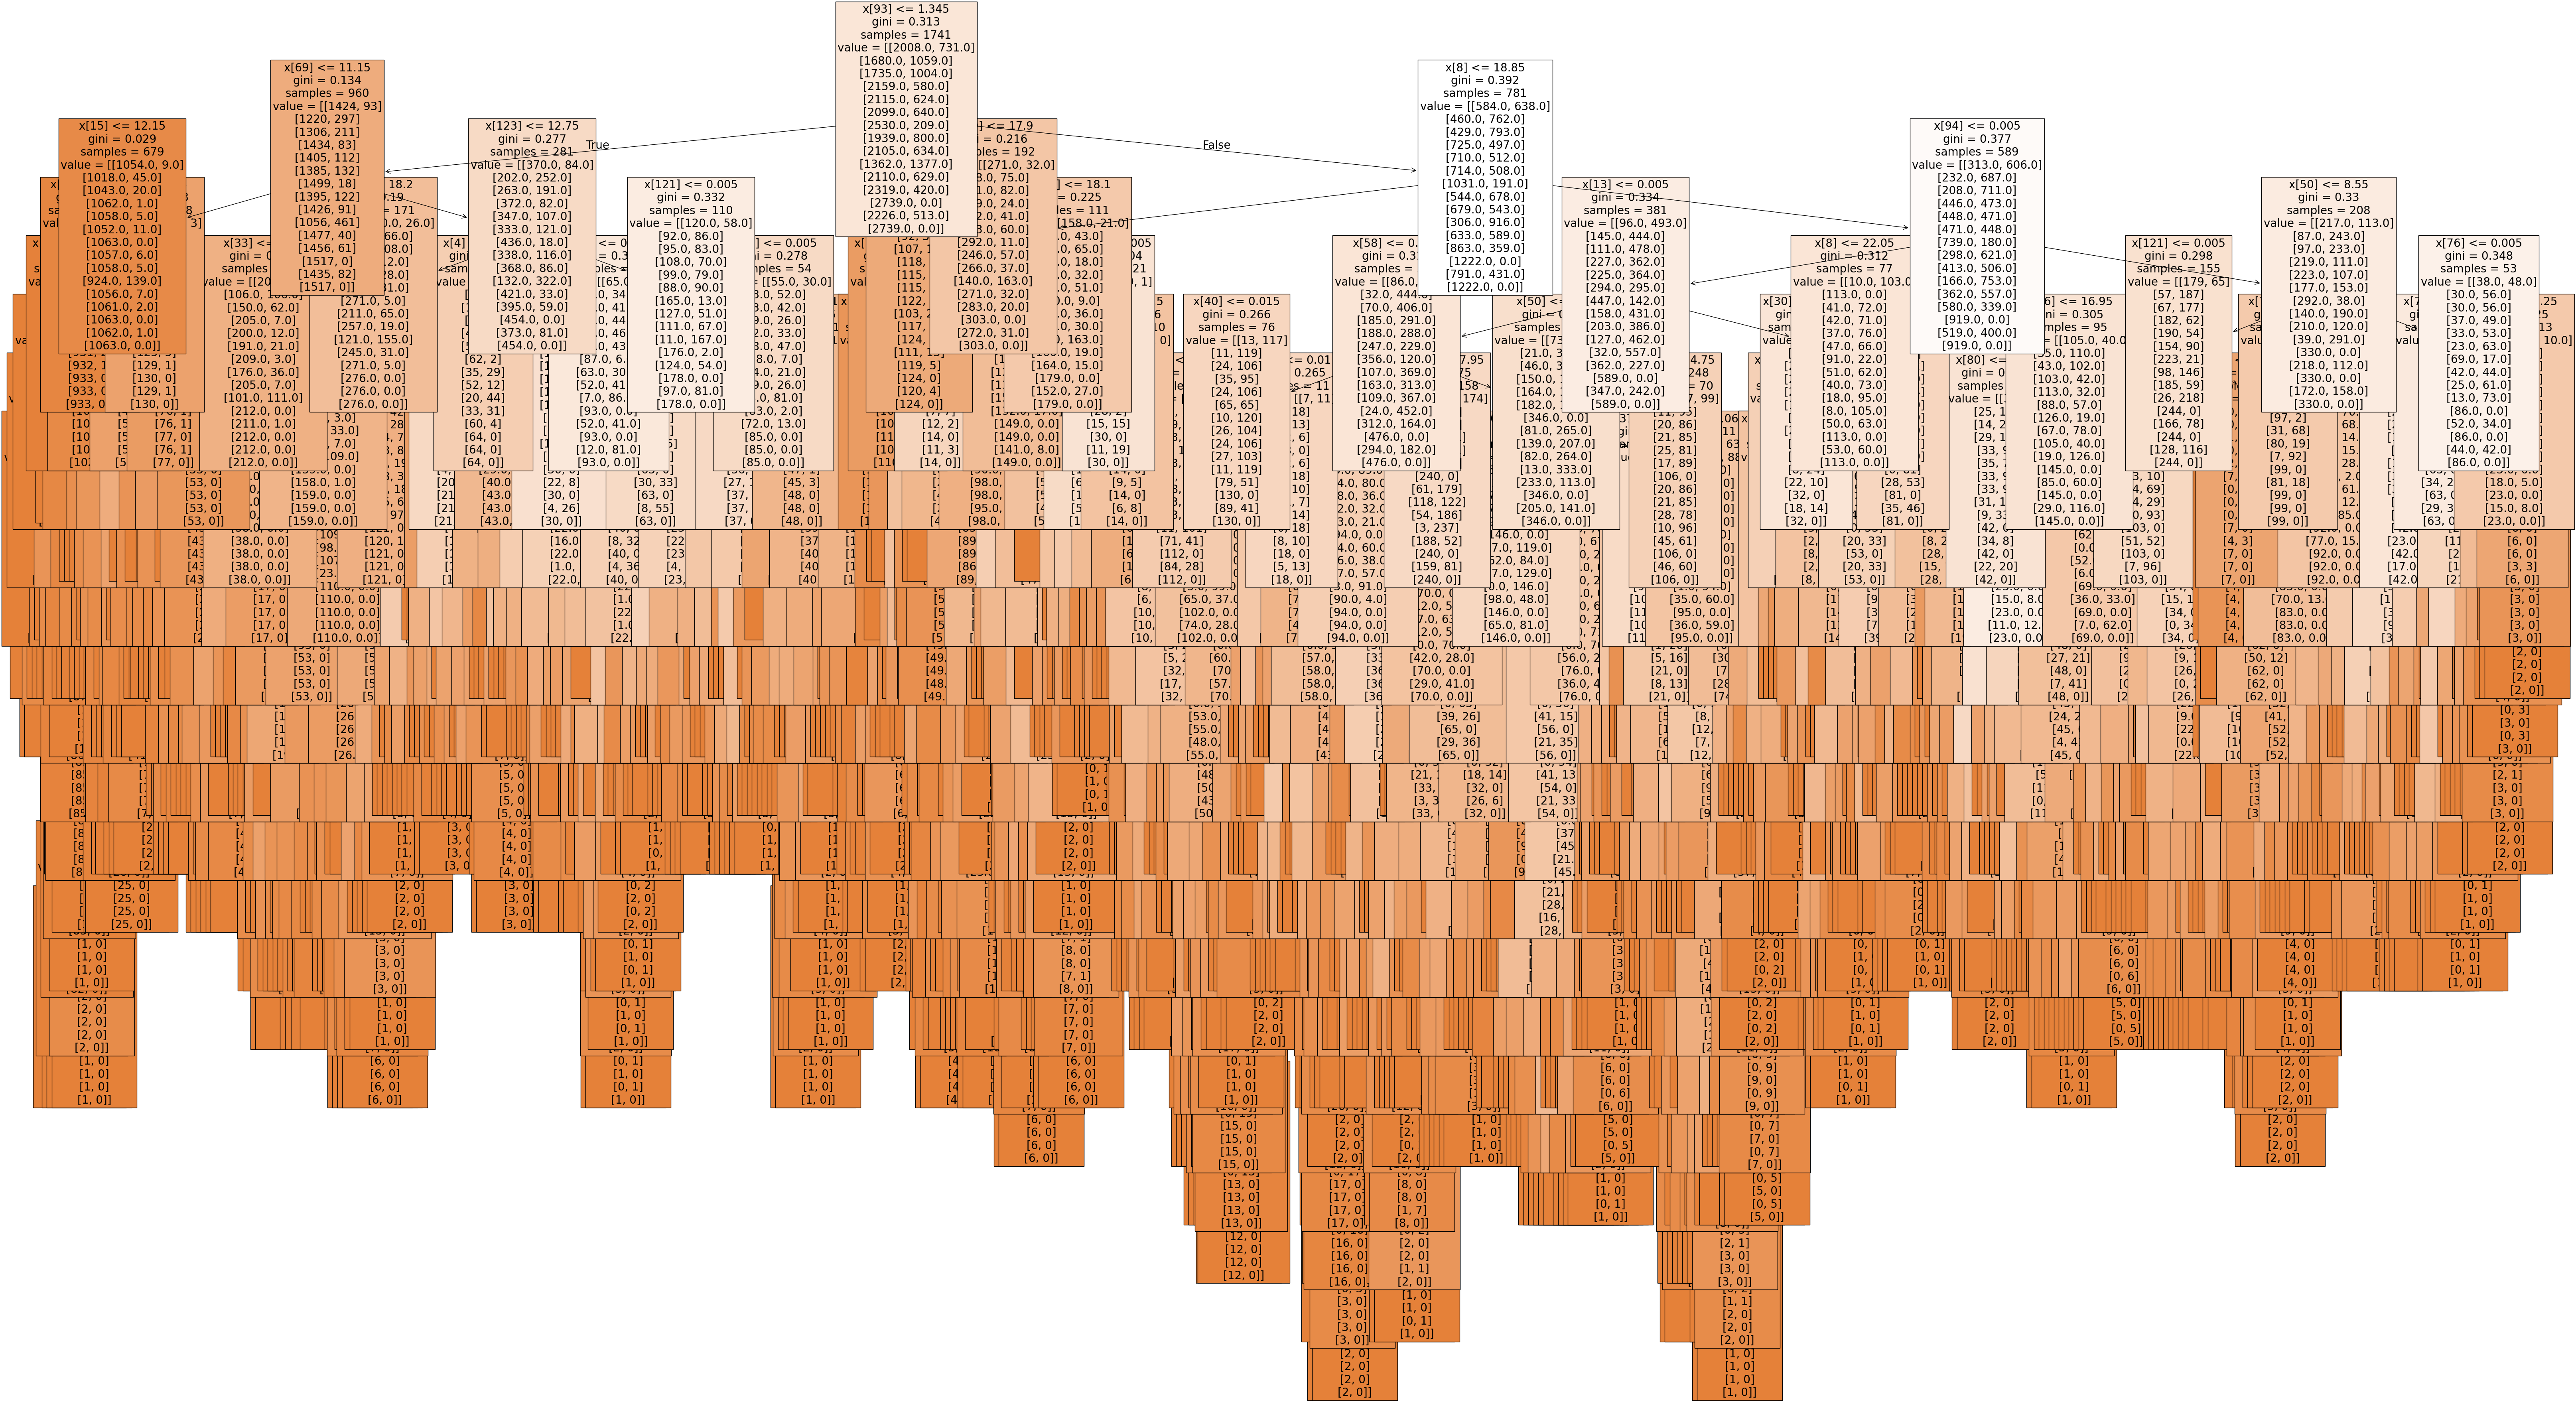

In [117]:
# Class-names = {0:'Unpleasant Weather', 1:'Pleasant Weather'}

fig = plt.figure(figsize=(80,40))
plot_tree(clf.estimators_[15], fontsize = 20, filled=True);

## 6. Feature Importance

In [127]:
# Retrieve feature importance from trained model

newarray = clf.feature_importances_
print(clf.feature_importances_.shape)
newarray

(135,)


array([3.11931545e-03, 3.52178914e-03, 3.41986082e-03, 3.22105333e-03,
       2.01906690e-02, 8.11351660e-03, 2.17345531e-02, 3.73693850e-03,
       3.39663263e-02, 3.75428673e-03, 3.59580669e-03, 4.24817798e-03,
       2.81167896e-03, 1.34752570e-02, 3.54094777e-03, 1.03524896e-02,
       5.59525907e-03, 8.32838145e-03, 3.40006621e-04, 0.00000000e+00,
       0.00000000e+00, 1.45372570e-03, 1.51943774e-02, 1.37724760e-03,
       1.43467920e-02, 5.78639719e-03, 2.80005296e-02, 2.04811600e-03,
       3.07424213e-03, 4.80687504e-03, 3.57436476e-03, 1.79986582e-02,
       5.26667861e-03, 2.34953427e-02, 3.25769200e-03, 3.84154032e-02,
       3.20256416e-03, 3.81442374e-03, 4.59472231e-03, 4.67698596e-03,
       1.64296025e-02, 5.68785339e-03, 2.03364002e-02, 2.90808661e-03,
       4.42975701e-02, 2.67893407e-03, 4.17986978e-03, 4.05252045e-03,
       4.05836371e-03, 9.52941270e-03, 4.56482486e-03, 6.81340858e-03,
       3.13588325e-03, 1.14673513e-02, 3.84550033e-03, 2.74699480e-03,
      

In [129]:
# Reshape new array

newarray = newarray.reshape(-1,15,9)
print(newarray.shape)
newarray

(1, 15, 9)


array([[[3.11931545e-03, 3.52178914e-03, 3.41986082e-03, 3.22105333e-03,
         2.01906690e-02, 8.11351660e-03, 2.17345531e-02, 3.73693850e-03,
         3.39663263e-02],
        [3.75428673e-03, 3.59580669e-03, 4.24817798e-03, 2.81167896e-03,
         1.34752570e-02, 3.54094777e-03, 1.03524896e-02, 5.59525907e-03,
         8.32838145e-03],
        [3.40006621e-04, 0.00000000e+00, 0.00000000e+00, 1.45372570e-03,
         1.51943774e-02, 1.37724760e-03, 1.43467920e-02, 5.78639719e-03,
         2.80005296e-02],
        [2.04811600e-03, 3.07424213e-03, 4.80687504e-03, 3.57436476e-03,
         1.79986582e-02, 5.26667861e-03, 2.34953427e-02, 3.25769200e-03,
         3.84154032e-02],
        [3.20256416e-03, 3.81442374e-03, 4.59472231e-03, 4.67698596e-03,
         1.64296025e-02, 5.68785339e-03, 2.03364002e-02, 2.90808661e-03,
         4.42975701e-02],
        [2.67893407e-03, 4.17986978e-03, 4.05252045e-03, 4.05836371e-03,
         9.52941270e-03, 4.56482486e-03, 6.81340858e-03, 3.13588325

In [131]:
# Collapse shape into one observation per weather station

sumarray = np.sum(newarray[0], axis=1)
sumarray

array([0.10102402, 0.05570229, 0.06649908, 0.10193737, 0.10594821,
       0.05048057, 0.03090714, 0.07043025, 0.10462082, 0.07016638,
       0.0929459 , 0.04764483, 0.0300788 , 0.06761673, 0.00399763])

In [133]:
# Convert the set of unique stations to a list

unique_stations_list = list(unique_stations)

In [135]:
important = pd.Series(sumarray, index = unique_stations_list)
important = important.sort_values(ascending = False)
important

OSLO          0.105948
BASEL         0.104621
MADRID        0.101937
STOCKHOLM     0.101024
MAASTRICHT    0.092946
BUDAPEST      0.070430
LJUBLJANA     0.070166
MUNCHENB      0.067617
KASSEL        0.066499
HEATHROW      0.055702
BELGRADE      0.050481
DUSSELDORF    0.047645
VALENTIA      0.030907
SONNBLICK     0.030079
DEBILT        0.003998
dtype: float64

In [137]:
# Create a df to associate weather stations with their importances

df_importance = pd.DataFrame({
    'Weather Station': unique_stations_list,
    'Importance': sumarray
})

df_importance = df_importance.sort_values(by='Importance', ascending = False)

['STOCKHOLM', 'HEATHROW', 'KASSEL', 'MADRID', 'OSLO', 'BELGRADE', 'VALENTIA', 'BUDAPEST', 'BASEL', 'LJUBLJANA', 'MAASTRICHT', 'DUSSELDORF', 'SONNBLICK', 'MUNCHENB', 'DEBILT']


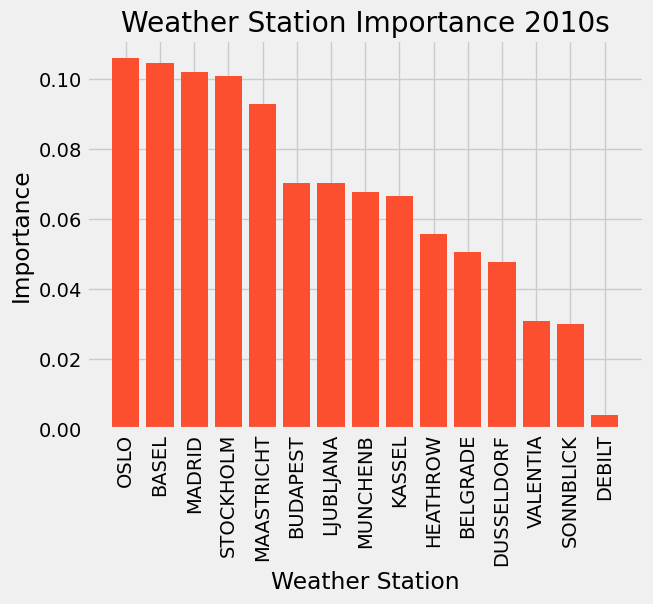

In [141]:
# Plot results

%matplotlib inline

plt.style.use('fivethirtyeight')
print(unique_stations_list)

plt.bar(df_importance['Weather Station'], df_importance['Importance'], orientation = 'vertical')
plt.xticks(rotation='vertical')
plt.xlabel('Weather Station')
plt.ylabel('Importance')
plt.title('Weather Station Importance 2010s')

plt.show()